<ipython-input-1-b8cd6e1571e8>:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_server1["Timestamp"] = pd.to_datetime(df_server1["Timestamp"])
<ipython-input-1-b8cd6e1571e8>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_server2["Timestamp"] = pd.to_datetime(df_server2["Timestamp"])


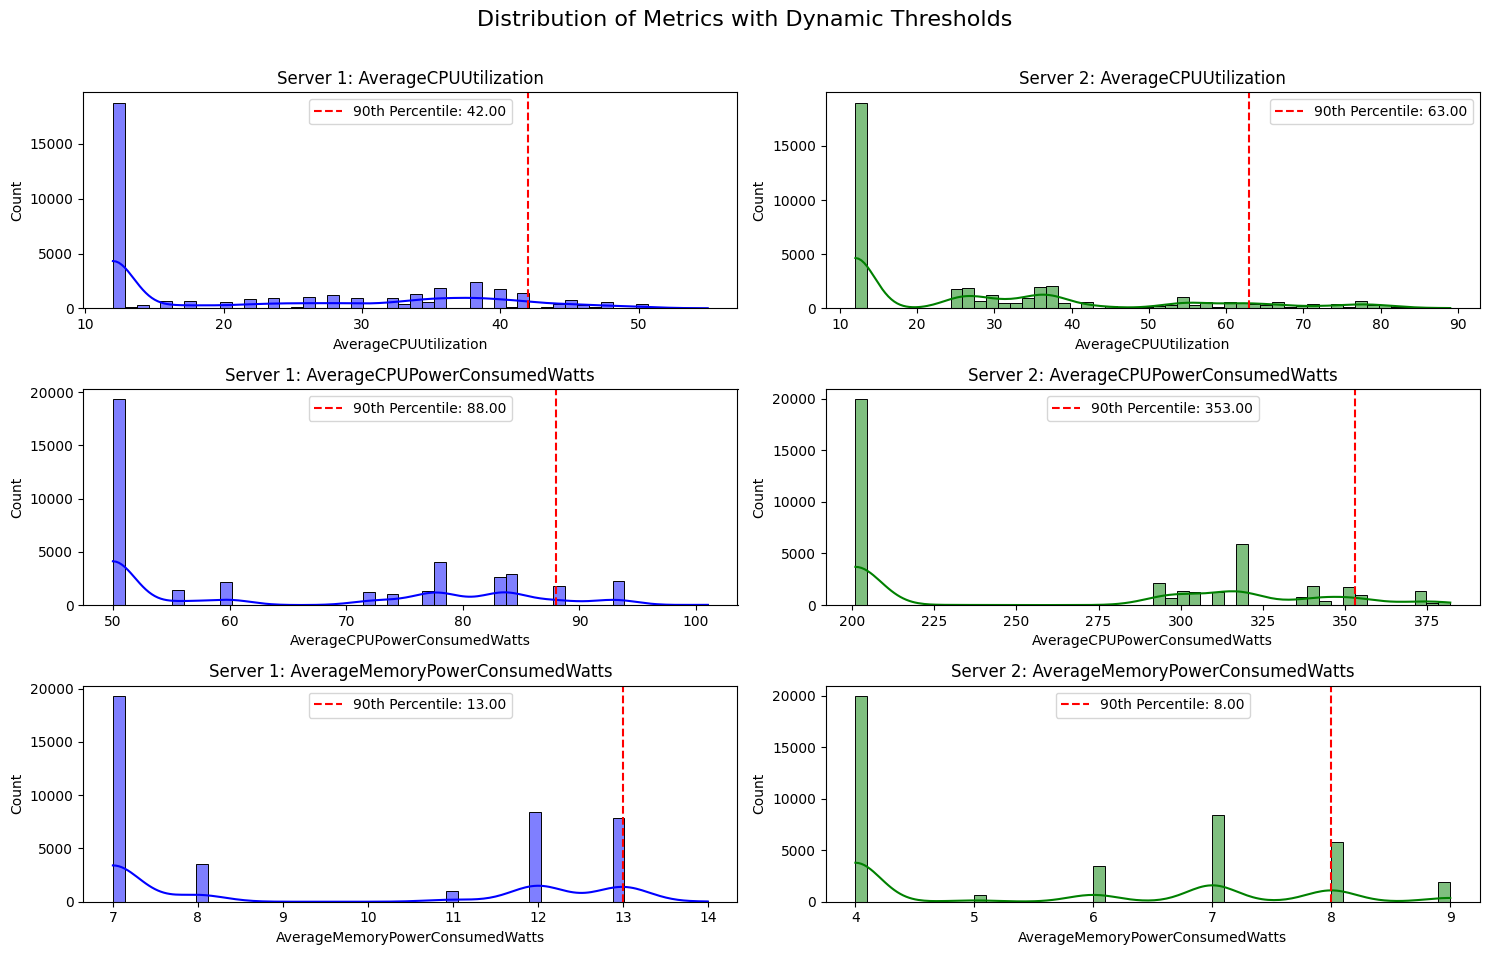

Server 1 Overload Percentage: 8.99%
Server 2 Overload Percentage: 12.46%
Recommendation: Server 2 is more overloaded. Shift workload from Server 2 to Server 1.


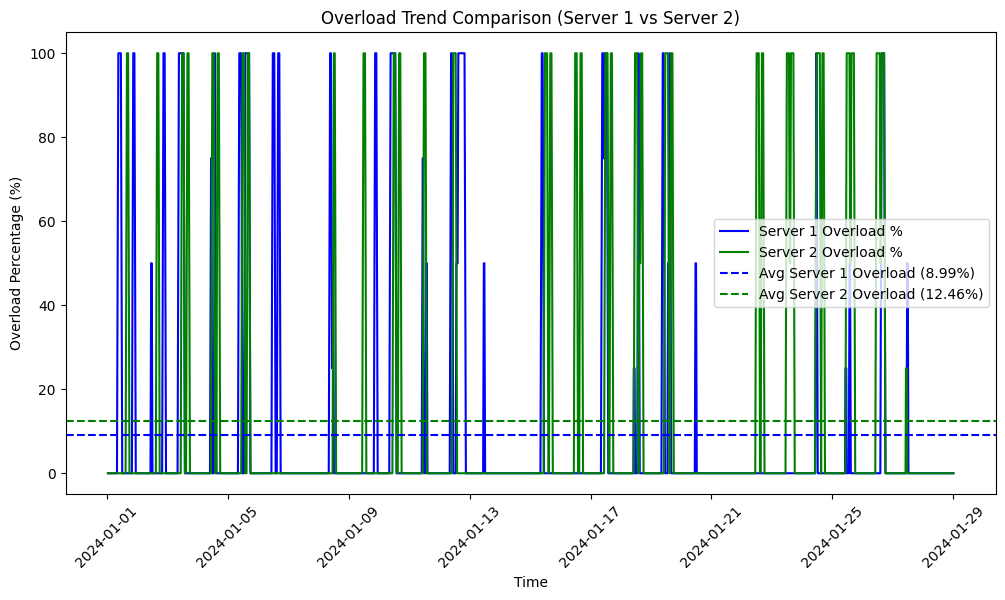

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_server1 = pd.read_csv("/content/timestamps_filled_132.csv")
df_server2 = pd.read_csv("/content/timestamps_filled_4wk.csv")

# Convert Timestamp to datetime
df_server1["Timestamp"] = pd.to_datetime(df_server1["Timestamp"])
df_server2["Timestamp"] = pd.to_datetime(df_server2["Timestamp"])

# Columns of interest
metrics = ["AverageCPUUtilization", "AverageCPUPowerConsumedWatts", "AverageMemoryPowerConsumedWatts"]

# Compute dynamic thresholds using the 90th percentile
thresholds_server1 = {metric: np.percentile(df_server1[metric], 90) for metric in metrics}
thresholds_server2 = {metric: np.percentile(df_server2[metric], 90) for metric in metrics}

# Plot distributions for threshold justification
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle("Distribution of Metrics with Dynamic Thresholds", fontsize=16)

for i, metric in enumerate(metrics):
    sns.histplot(df_server1[metric], bins=50, kde=True, ax=axes[i, 0], color='blue')
    axes[i, 0].axvline(thresholds_server1[metric], color='red', linestyle='dashed', label=f"90th Percentile: {thresholds_server1[metric]:.2f}")
    axes[i, 0].set_title(f"Server 1: {metric}")
    axes[i, 0].legend()

    sns.histplot(df_server2[metric], bins=50, kde=True, ax=axes[i, 1], color='green')
    axes[i, 1].axvline(thresholds_server2[metric], color='red', linestyle='dashed', label=f"90th Percentile: {thresholds_server2[metric]:.2f}")
    axes[i, 1].set_title(f"Server 2: {metric}")
    axes[i, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# Identify overload conditions
df_server1["Overloaded"] = (df_server1["AverageCPUUtilization"] > thresholds_server1["AverageCPUUtilization"]) | \
                           (df_server1["AverageCPUPowerConsumedWatts"] > thresholds_server1["AverageCPUPowerConsumedWatts"]) | \
                           (df_server1["AverageMemoryPowerConsumedWatts"] > thresholds_server1["AverageMemoryPowerConsumedWatts"])

df_server2["Overloaded"] = (df_server2["AverageCPUUtilization"] > thresholds_server2["AverageCPUUtilization"]) | \
                           (df_server2["AverageCPUPowerConsumedWatts"] > thresholds_server2["AverageCPUPowerConsumedWatts"]) | \
                           (df_server2["AverageMemoryPowerConsumedWatts"] > thresholds_server2["AverageMemoryPowerConsumedWatts"])

# Compute overload percentages
server1_overload_pct = df_server1["Overloaded"].mean() * 100
server2_overload_pct = df_server2["Overloaded"].mean() * 100

# Recommendation logic
if server1_overload_pct > server2_overload_pct:
    recommendation = "Server 1 is more overloaded. Shift workload from Server 1 to Server 2."
elif server2_overload_pct > server1_overload_pct:
    recommendation = "Server 2 is more overloaded. Shift workload from Server 2 to Server 1."
else:
    recommendation = "Both servers are balanced. No workload shift required."

print(f"Server 1 Overload Percentage: {server1_overload_pct:.2f}%")
print(f"Server 2 Overload Percentage: {server2_overload_pct:.2f}%")
print(f"Recommendation: {recommendation}")

# Plot overload trends over time
plt.figure(figsize=(12, 6))
plt.plot(df_server1["Timestamp"], df_server1["Overloaded"].rolling(window=60).mean() * 100, label="Server 1 Overload %", color='blue')
plt.plot(df_server2["Timestamp"], df_server2["Overloaded"].rolling(window=60).mean() * 100, label="Server 2 Overload %", color='green')

plt.axhline(server1_overload_pct, color='blue', linestyle='dashed', label=f"Avg Server 1 Overload ({server1_overload_pct:.2f}%)")
plt.axhline(server2_overload_pct, color='green', linestyle='dashed', label=f"Avg Server 2 Overload ({server2_overload_pct:.2f}%)")

plt.xlabel("Time")
plt.ylabel("Overload Percentage (%)")
plt.title("Overload Trend Comparison (Server 1 vs Server 2)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

<ipython-input-2-88adc6df7312>:66: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Timestamp"] = pd.to_datetime(df["Timestamp"])


New Start Date: 2025-03-01 00:00:00
New End Date: 2025-03-28 23:59:00
{'Status': 'Warning', 'Metric': 'AverageCPUPowerConsumedWatts', 'Threshold': 275, 'First Exceed Timestamp': Timestamp('2025-03-01 08:11:00'), 'Last Exceed Timestamp': Timestamp('2025-03-27 22:00:00'), 'Estimated Failure Time': '26 days 13:49:00'}


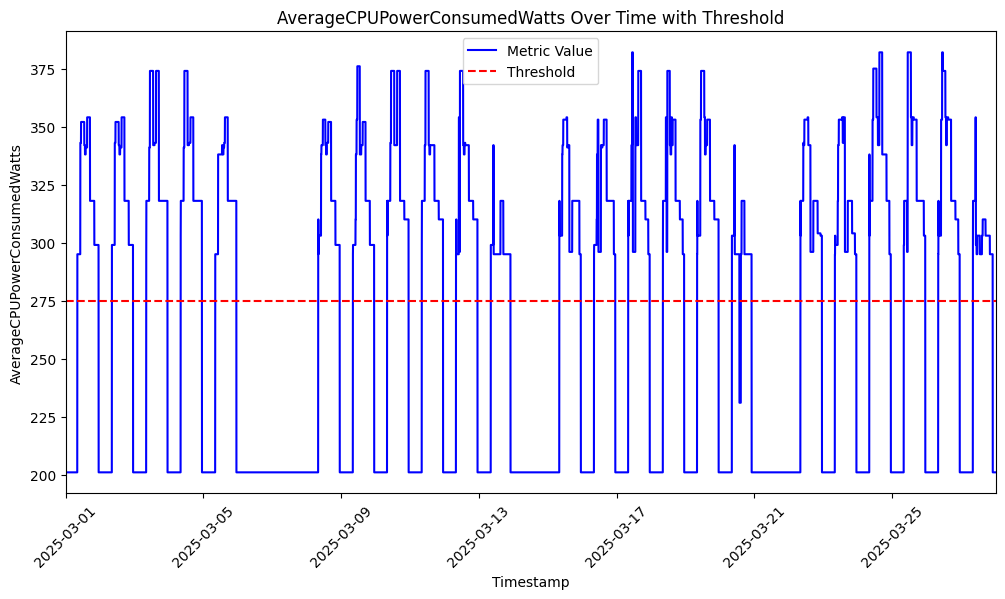


================ WARNING =================
  AverageCPUPowerConsumedWatts exceeded the threshold of 275W at 2025-03-01 08:11:00
  Estimated Time to Hardware Failure: 26 days 13:49:00

{'Status': 'Warning', 'Metric': 'AverageSystemPowerConsumedWatts', 'Threshold': 500, 'First Exceed Timestamp': Timestamp('2025-03-01 10:16:00'), 'Last Exceed Timestamp': Timestamp('2025-03-27 10:15:00'), 'Estimated Failure Time': '25 days 23:59:00'}


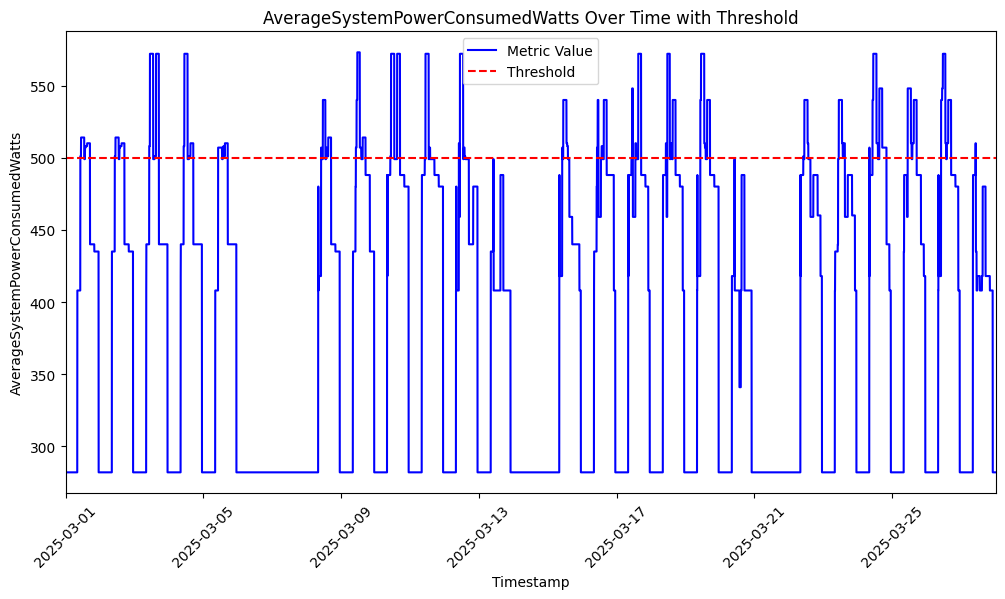


================ WARNING =================
  AverageSystemPowerConsumedWatts exceeded the threshold of 500W at 2025-03-01 10:16:00
  Estimated Time to Hardware Failure: 25 days 23:59:00



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

def predict_hardware_failure(df, column, threshold, time_column='Timestamp'):
    """
    Detects when a metric exceeds a threshold and predicts the approximate time to hardware failure.
    """
    df[time_column] = pd.to_datetime(df[time_column])

    # Identify points where the value exceeds the threshold
    failure_data = df[df[column] > threshold]

    if failure_data.empty:
        print(f"No Warning: {column} values are within safe limits.")
        return {"Status": "No Warning", "Message": f"{column} values are within safe limits."}

    # Calculate time difference from first threshold crossing to max value
    first_exceed_time = failure_data[time_column].iloc[0]
    last_exceed_time = failure_data[time_column].iloc[-1]
    estimated_failure_time = last_exceed_time - first_exceed_time

    return {
        "Status": "Warning",
        "Metric": column,
        "Threshold": threshold,
        "First Exceed Timestamp": first_exceed_time,
        "Last Exceed Timestamp": last_exceed_time,
        "Estimated Failure Time": str(estimated_failure_time)
    }

def plot_threshold_exceedances(df, column, threshold, time_column='Timestamp'):
    """
    Plots the metric over time, highlighting threshold exceedances.
    """
    df[time_column] = pd.to_datetime(df[time_column])
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=df[time_column], y=df[column], label='Metric Value', color='blue')
    plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')
    plt.xlabel('Timestamp')
    plt.ylabel(column)
    plt.title(f'{column} Over Time with Threshold')
    plt.legend()
    plt.xticks(rotation=45)
    plt.xlim(pd.to_datetime("2025-03-01"), pd.to_datetime("2025-03-28"))
    plt.savefig("/content/System.png", dpi=300, bbox_inches='tight')
    plt.show()

    failure_data = df[df[column] > threshold]
    if not failure_data.empty:
        first_exceed_time = failure_data[time_column].iloc[0]
        last_exceed_time = failure_data[time_column].iloc[-1]
        estimated_failure_time = last_exceed_time - first_exceed_time

        print("\n================ WARNING =================")
        print(f"  {column} exceeded the threshold of {threshold}W at {first_exceed_time}")
        print(f"  Estimated Time to Hardware Failure: {estimated_failure_time}")
        print("========================================\n")

# Load dataset
df = pd.read_csv("/content/timestamps_filled_4wk.csv")

# Convert timestamp to datetime format
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Define the new desired start and end dates
new_start = pd.to_datetime("2025-03-01")
new_end = pd.to_datetime("2025-03-27")

# Get the original dataset's start and end dates
original_start = df["Timestamp"].min()
original_end = df["Timestamp"].max()

# Compute the required time shift
time_shift = new_start - original_start

# Apply the shift to all timestamps
df["Timestamp"] = df["Timestamp"] + time_shift

# Verify the new date rangea
print(f"New Start Date: {df['Timestamp'].min()}")
print(f"New End Date: {df['Timestamp'].max()}")

# Define thresholds
thresholds = {
    'AverageCPUPowerConsumedWatts': 275,
    'AverageSystemPowerConsumedWatts': 500,
}

# Run analysis for each metric
for metric, threshold in thresholds.items():
    result = predict_hardware_failure(df, metric, threshold)
    print(result)
    plot_threshold_exceedances(df, metric, threshold)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Load datasets
file_path1 = "/content/timestamps_filled_4wk.csv"
file_path2 = "/content/timestamps_filled_132.csv"
df1 = pd.read_csv(file_path1)
df2 = pd.read_csv(file_path2)

# Normalize data
scaler1 = MinMaxScaler()
df1_scaled = pd.DataFrame(scaler1.fit_transform(df1.iloc[:, 1:]), columns=df1.columns[1:])
scaler2 = MinMaxScaler()
df2_scaled = pd.DataFrame(scaler2.fit_transform(df2.iloc[:, 1:]), columns=df2.columns[1:])

class ProbSparseSelfAttention(nn.Module):
    def __init__(self, input_dim, num_heads=8, dropout=0.1):
        super(ProbSparseSelfAttention, self).__init__()
        self.num_heads = num_heads
        self.qkv_proj = nn.Linear(input_dim, input_dim * 3)  # Query, Key, Value
        self.fc_out = nn.Linear(input_dim, input_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_length, embed_dim = x.shape
        qkv = self.qkv_proj(x).reshape(batch_size, seq_length, 3, self.num_heads, embed_dim // self.num_heads)
        q, k, v = qkv[:, :, 0], qkv[:, :, 1], qkv[:, :, 2]

        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / (embed_dim ** 0.5)

        # Apply sparse attention (keep top-k values)
        top_k = int(seq_length * 0.2)  # Keeping top 20% attention scores
        top_values, _ = torch.topk(attn_scores, top_k, dim=-1)
        sparse_mask = attn_scores >= top_values[:, :, -1].unsqueeze(-1)
        attn_scores = attn_scores.masked_fill(~sparse_mask, float('-inf'))

        attn_weights = F.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        out = torch.matmul(attn_weights, v).reshape(batch_size, seq_length, embed_dim)
        return self.fc_out(out)

class TCNInformer(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=3, kernel_size=3, num_heads=8):
        super(TCNInformer, self).__init__()
        self.tcn_layers = nn.ModuleList([
            TCNBlock(input_dim if i == 0 else hidden_dim, hidden_dim, kernel_size, dilation=2**i)
            for i in range(num_layers)
        ])
        self.attention = ProbSparseSelfAttention(hidden_dim, num_heads)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        for layer in self.tcn_layers:
            x = layer(x)
        x = x.permute(0, 2, 1)  # Reshape for attention (batch, seq_length, features)
        x = self.attention(x)
        x = self.fc(x[:, -1, :])  # Use last time step
        return x


# ProbSparse Attention Mechanism from Informer
class ProbAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super(ProbAttention, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout)

    def forward(self, query, key, value):
        attn_output, _ = self.attn(query, key, value)
        return attn_output

# TCN Block remains the same
class TCNBlock(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3, dilation=1):
        super(TCNBlock, self).__init__()
        self.conv = nn.Conv1d(input_dim, hidden_dim, kernel_size, padding=dilation, dilation=dilation)
        self.relu = nn.ReLU()
        self.batch_norm = nn.BatchNorm1d(hidden_dim)

    def forward(self, x):
        x = self.conv(x)
        x = self.relu(x)
        x = self.batch_norm(x)
        return x

# Modified Model with ProbSparse Attention
class TCNInformer(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=3, kernel_size=3, num_heads=8):
        super(TCNInformer, self).__init__()
        self.tcn_layers = nn.ModuleList([
            TCNBlock(input_dim if i == 0 else hidden_dim, hidden_dim, kernel_size, dilation=2**i)
            for i in range(num_layers)
        ])
        self.attention = ProbAttention(embed_dim=hidden_dim, num_heads=num_heads)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        for layer in self.tcn_layers:
            x = layer(x)
        x = x.permute(2, 0, 1)
        x = self.attention(x, x, x)
        x = x.permute(1, 2, 0)
        x = self.fc(x[:, :, -1])
        return x


# Function to prepare dataset
def prepare_dataset(df_scaled):
    sequence_length = 30
    X, y = [], []
    for i in range(len(df_scaled) - sequence_length):
        X.append(df_scaled.iloc[i:i+sequence_length, :].values)
        y.append(df_scaled.iloc[i+sequence_length, :].values.mean())
    X = np.array(X)
    y = np.array(y)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Training function
def train_model(model, train_loader, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch.permute(0, 2, 1))
            loss = criterion(outputs.squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_loader):.4f}")

# Model evaluation function
def classify_server_health(anomalies, tolerance=0.05):
    total_points = len(anomalies)
    anomaly_count = np.sum(anomalies)

    anomaly_ratio = anomaly_count / total_points  # Percentage of anomalies

    print(f"\nServer Health Check:")
    print(f"Total Points: {total_points}, Anomalies: {anomaly_count} ({anomaly_ratio*100:.2f}%)")

    if anomaly_ratio > tolerance:  # More than 5% anomalies → issue detected
        print("Issue Detected in Server Health!")
    else:
        print("Server Health is Good.")

# Update model evaluation to include health classification
def evaluate_model(model, test_loader):
    model.eval()
    predictions, actuals = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch.permute(0, 2, 1)).squeeze()
            predictions.extend(outputs.cpu().numpy())  # Ensure compatibility with GPU
            actuals.extend(y_batch.cpu().numpy())

    mae = mean_absolute_error(actuals, predictions)
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(actuals, predictions)
    print(f"\nEvaluation:\nMAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}, R² Score: {r2:.4f}")

    # Detect anomalies
    anomalies = detect_anomalies(predictions, actuals)

    # Classify Server Health
    classify_server_health(anomalies)

    return np.array(predictions), np.array(actuals)


# Anomaly detection function
def detect_anomalies(predictions, actuals, threshold_percentile=99):
    residuals = np.abs(np.array(actuals) - np.array(predictions))
    threshold = np.percentile(residuals, threshold_percentile)
    anomalies = residuals > threshold
    print(f"\nAnomaly Detection:\nThreshold (99th percentile): {threshold:.4f}")
    print(f"Total Anomalies Detected: {np.sum(anomalies)}")
    return anomalies

# Train and evaluate for both datasets
for df_scaled, name in zip([df1_scaled, df2_scaled], ["Dataset 1", "Dataset 2"]):
    print(f"\nTraining on {name}")
    X, y = prepare_dataset(df_scaled)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64, shuffle=False)
    model = TCNInformer(input_dim=X.shape[2], hidden_dim=128, num_heads=8)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.MSELoss()
    train_model(model, train_loader)
    predictions, actuals = evaluate_model(model, test_loader)



# Compare server utilization
server1_avg_util = df1_scaled.mean().mean()
server2_avg_util = df2_scaled.mean().mean()
if server1_avg_util > server2_avg_util:
    print("Server 1 is more utilized. Shifting load to Server 2.")
elif server2_avg_util > server1_avg_util:
    print("Server 2 is more utilized. Shifting load to Server 1.")
else:
    print("Both servers have balanced utilization.")



Training on Dataset 1
Epoch 1/10 - Loss: 0.0057
Epoch 2/10 - Loss: 0.0012
Epoch 3/10 - Loss: 0.0009
Epoch 4/10 - Loss: 0.0007
Epoch 5/10 - Loss: 0.0007
Epoch 6/10 - Loss: 0.0006
Epoch 7/10 - Loss: 0.0007
Epoch 8/10 - Loss: 0.0006
Epoch 9/10 - Loss: 0.0006
Epoch 10/10 - Loss: 0.0006

Evaluation:
MAE: 0.0114, MSE: 0.0005, RMSE: 0.0225, R² Score: 0.9946

Anomaly Detection:
Threshold (99th percentile): 0.0487
Total Anomalies Detected: 81

Server Health Check:
Total Points: 8058, Anomalies: 81 (1.01%)
Server Health is Good.

Training on Dataset 2
Epoch 1/10 - Loss: 0.0053
Epoch 2/10 - Loss: 0.0011
Epoch 3/10 - Loss: 0.0008
Epoch 4/10 - Loss: 0.0008
Epoch 5/10 - Loss: 0.0007
Epoch 6/10 - Loss: 0.0008
Epoch 7/10 - Loss: 0.0006
Epoch 8/10 - Loss: 0.0006
Epoch 9/10 - Loss: 0.0006
Epoch 10/10 - Loss: 0.0006

Evaluation:
MAE: 0.0142, MSE: 0.0005, RMSE: 0.0228, R² Score: 0.9863

Anomaly Detection:
Threshold (99th percentile): 0.0571
Total Anomalies Detected: 81

Server Health Check:
Total Points: